<a href="https://www.kaggle.com/code/nikita2901699/practical-nn?scriptVersionId=292791580" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [126]:
import torch  
from torchvision import datasets, transforms 

In [127]:
data_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"

In [128]:
dataset0 = datasets.ImageFolder(data_dir)

In [129]:
len(dataset)

3527

In [130]:
img, label = dataset[3526]

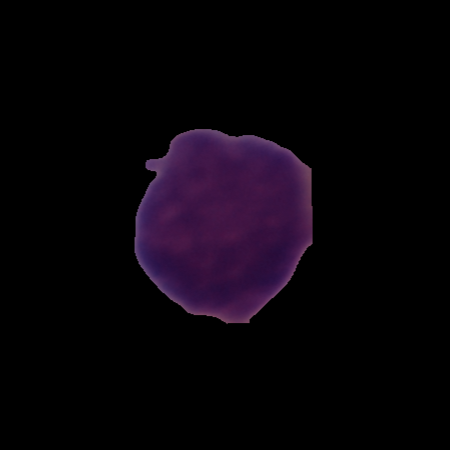

In [131]:
img

In [132]:
dataset0.classes

['all', 'hem']

In [133]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
dataset1 = datasets.ImageFolder(data_dir1)

data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
dataset2 = datasets.ImageFolder(data_dir2)

In [134]:
dataset0.classes
dataset1.classes
dataset2.classes

['all', 'hem']

In [135]:
dataset_all = torch.utils.data.ConcatDataset([dataset0, dataset1, dataset2])

In [136]:
len(dataset_all)

10661

In [137]:
data_train, data_test = torch.utils.data.random_split(dataset_all,[0.8, 0.2])

In [138]:
len(data_train)


8529

In [139]:
len(data_test)


2132

In [140]:
img, label = data_train[5000]

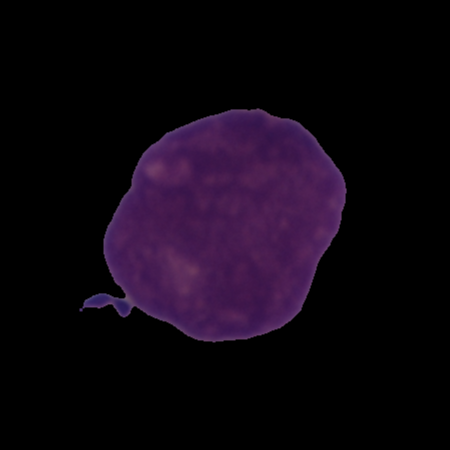

In [141]:
img

In [149]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.CenterCrop(180),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [152]:
train_transform(img).shape

torch.Size([3, 180, 180])

In [156]:
test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.CenterCrop(180),
    transforms.ToTensor()
    ]
)

In [158]:
test_transform(img).shape

torch.Size([3, 180, 180])

In [176]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [163]:
train_data = TransformDataset(data_train,train_transform)

In [166]:
test_data = TransformDataset(data_test,test_transform)

In [168]:
len(test_data)

2132

In [170]:
test_data[2100]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [177]:
train_loader = DataLoader(train_data, batch_size=256)

In [181]:
test_loader = DataLoader(test_data, batch_size=256)


In [188]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 


torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([84, 3, 180, 180])
torch.Size([84])


(180, 180, 3)


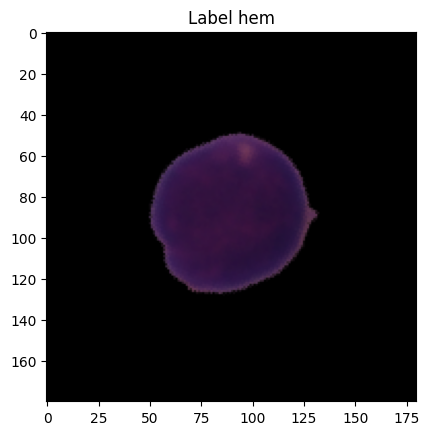

(180, 180, 3)


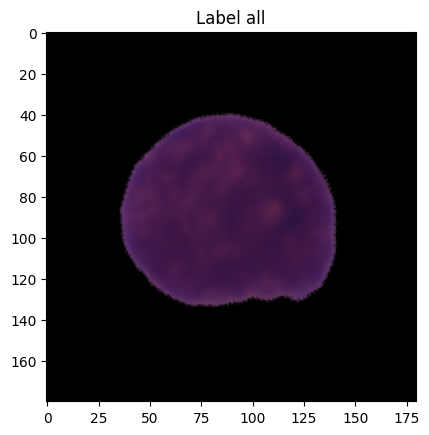

(180, 180, 3)


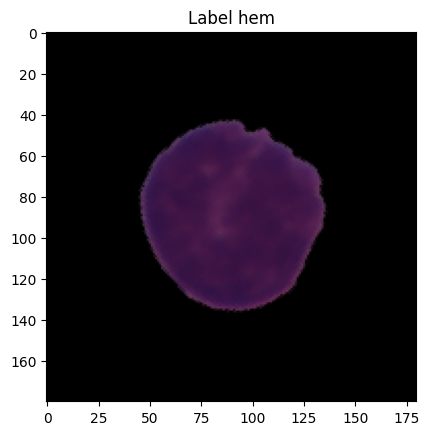

In [189]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

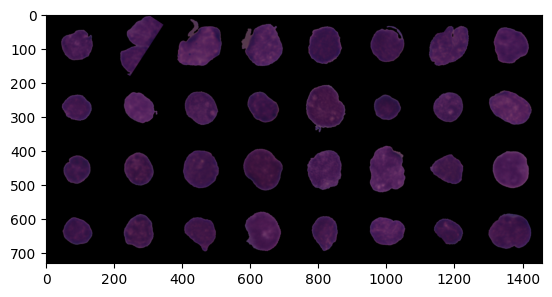

In [190]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)